# Clasificación binaria de activación con EDA y PPG

Este notebook:
- construye un dataset `raw`
- construye un dataset `processed`
- guarda ambos CSV
- evalúa ambos con `RandomForest` usando leave-one-subject-out

Clases:
- `baseline` -> Activación baja
- `video2` -> Activación baja
- `squat` -> Activación alta
- `video1` -> Activación alta

La diferencia clave respecto al esquema anterior es que el pipeline
procesado se aplica primero a la señal completa del sujeto y solo después
se segmenta por tarea usando `stamps`.


## Configuración

Usamos ventanas de **5 s** sin solapamiento.
La validación se hace con `GroupKFold`, agrupando por sujeto para evitar leakage entre ventanas del mismo usuario.


In [14]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd


def resolve_pipeline_dir():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "pipeline", cwd.parent]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "preprocessing").exists():
            return candidate
    raise FileNotFoundError("No se ha podido localizar la carpeta pipeline desde el directorio de trabajo actual.")


PIPELINE_DIR = resolve_pipeline_dir()
DATA_DIR = PIPELINE_DIR / "data"
OUTPUT_DIR = DATA_DIR / "ml"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PIPELINE_DIR) not in sys.path:
    sys.path.insert(0, str(PIPELINE_DIR))

from data_layout import list_subject_ids, load_subject_signal, load_subject_stamps, segment_signal
from preprocessing.filtering import butterworth_bvp, gaussian_gsr
from preprocessing.outliers import IQR
from preprocessing.resampling import resample_with_spline

try:
    from tsfresh import extract_features
    from tsfresh.feature_extraction import EfficientFCParameters
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Este notebook necesita tsfresh. Instala las dependencias antes de ejecutarlo.") from exc

try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import f1_score
    from sklearn.model_selection import GroupKFold
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Este notebook necesita scikit-learn. Instala las dependencias antes de ejecutarlo.") from exc

WINDOW_SIZE_S = 5
STEP_SIZE_S = 5
EDA_TARGET_FS = 15
PPG_TARGET_FS = 50

LABEL_TO_TARGET = {
    "baseline": 0,
    "video2": 0,
    "squat": 1,
    "video1": 1,
}

TARGET_TO_LABEL = {
    0: "Activacion_baja",
    1: "Activacion_alta",
}

CLASS_NAMES = ["baseline", "squat", "video1", "video2"]

RAW_DATASET_PATH = OUTPUT_DIR / f"emotion_2class_activation_raw_{WINDOW_SIZE_S}s.csv"
PROCESSED_DATASET_PATH = OUTPUT_DIR / f"emotion_2class_activation_processed_{WINDOW_SIZE_S}s.csv"

print("Pipeline dir:", PIPELINE_DIR)
print("Sujetos:", list_subject_ids(DATA_DIR))


Pipeline dir: C:\Users\Usuario\Documents\GitHub\Caepia\pipeline
Sujetos: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']


## Construcción de datasets


In [15]:
def preprocess_eda_full(raw_df):
    resampled_df = resample_with_spline(raw_df, target_frequency=EDA_TARGET_FS, signal_col="EA")
    outlier_df = IQR(resampled_df.copy(), "EA")
    return gaussian_gsr(outlier_df.copy(), "EA", sampling_rate=EDA_TARGET_FS)


def preprocess_ppg_full(raw_df):
    resampled_df = resample_with_spline(raw_df, target_frequency=PPG_TARGET_FS, signal_col="PG")
    outlier_df = IQR(resampled_df.copy(), "PG")
    return butterworth_bvp(outlier_df.copy(), "PG", sampling_rate=PPG_TARGET_FS)


def make_windows(df, signal_col, sample_prefix):
    base = df[["Timestamp", signal_col]].copy().sort_values("Timestamp").reset_index(drop=True)
    if base.empty:
        return pd.DataFrame(columns=["id", "time", "kind", "value"])
    base["time_rel"] = base["Timestamp"] - base["Timestamp"].iloc[0]
    max_time = float(base["time_rel"].iloc[-1])
    starts = np.arange(0, max_time - WINDOW_SIZE_S + 1e-9, STEP_SIZE_S, dtype=float)

    windows = []
    for window_index, start_s in enumerate(starts):
        end_s = start_s + WINDOW_SIZE_S
        window_df = base[(base["time_rel"] >= start_s) & (base["time_rel"] < end_s)].copy()
        if window_df.empty:
            continue
        sample_id = f"{sample_prefix}_W{window_index:02d}"
        window_df["id"] = sample_id
        window_df["time"] = window_df["time_rel"]
        window_df["kind"] = signal_col
        window_df["value"] = window_df[signal_col]
        windows.append(window_df[["id", "time", "kind", "value"]])

    if windows:
        return pd.concat(windows, ignore_index=True)
    return pd.DataFrame(columns=["id", "time", "kind", "value"])


def extract_dataset(use_processed):
    subject_ids = list_subject_ids(DATA_DIR)
    eda_parts = []
    ppg_parts = []
    labels = []

    for user_id in subject_ids:
        eda_raw_full = load_subject_signal(DATA_DIR, "eda", user_id, "EA")
        ppg_raw_full = load_subject_signal(DATA_DIR, "ppg", user_id, "PG")
        stamps = load_subject_stamps(DATA_DIR, user_id)

        eda_source = preprocess_eda_full(eda_raw_full) if use_processed else eda_raw_full
        ppg_source = preprocess_ppg_full(ppg_raw_full) if use_processed else ppg_raw_full

        for label_name in CLASS_NAMES:
            target = LABEL_TO_TARGET[label_name]
            eda_df = segment_signal(eda_source, stamps, label_name)
            ppg_df = segment_signal(ppg_source, stamps, label_name)

            sample_prefix = f"{user_id}_{label_name}"
            eda_long = make_windows(eda_df, "EA", sample_prefix)
            ppg_long = make_windows(ppg_df, "PG", sample_prefix)

            common_ids = sorted(set(eda_long["id"].unique()) & set(ppg_long["id"].unique()))
            eda_long = eda_long[eda_long["id"].isin(common_ids)].copy()
            ppg_long = ppg_long[ppg_long["id"].isin(common_ids)].copy()

            labels.extend({"sample_id": sample_id, "user_id": user_id, "target": target} for sample_id in common_ids)

            if not eda_long.empty:
                eda_parts.append(eda_long)
            if not ppg_long.empty:
                ppg_parts.append(ppg_long)

    eda_long_df = pd.concat(eda_parts, ignore_index=True)
    ppg_long_df = pd.concat(ppg_parts, ignore_index=True)
    labels_df = pd.DataFrame(labels).drop_duplicates().sort_values(["user_id", "sample_id"]).reset_index(drop=True)

    eda_features = extract_features(
        eda_long_df,
        column_id="id",
        column_sort="time",
        column_kind="kind",
        column_value="value",
        default_fc_parameters=EfficientFCParameters(),
        n_jobs=4,
        disable_progressbar=True,
    )
    ppg_features = extract_features(
        ppg_long_df,
        column_id="id",
        column_sort="time",
        column_kind="kind",
        column_value="value",
        default_fc_parameters=EfficientFCParameters(),
        n_jobs=4,
        disable_progressbar=True,
    )

    eda_features = eda_features.add_prefix("eda__").reset_index().rename(columns={"index": "sample_id"})
    ppg_features = ppg_features.add_prefix("ppg__").reset_index().rename(columns={"index": "sample_id"})

    return (
        labels_df
        .merge(eda_features, on="sample_id", how="inner")
        .merge(ppg_features, on="sample_id", how="inner")
        .drop(columns=["sample_id"])
        .sort_values(["user_id", "target"])
        .reset_index(drop=True)
    )


raw_dataset_df = extract_dataset(use_processed=False)
processed_dataset_df = extract_dataset(use_processed=True)

raw_dataset_df.to_csv(RAW_DATASET_PATH, index=False)
processed_dataset_df.to_csv(PROCESSED_DATASET_PATH, index=False)

print("Raw shape:", raw_dataset_df.shape)
print("Processed shape:", processed_dataset_df.shape)


Raw shape: (628, 1556)
Processed shape: (628, 1556)


## Limpieza de features


In [16]:
def clean_feature_columns(dataset_df):
    keep_cols = ["user_id", "target"]
    feature_cols = [col for col in dataset_df.columns if col not in keep_cols]
    non_nan_feature_cols = [col for col in feature_cols if not dataset_df[col].isna().any()]
    zero_var_feature_cols = [col for col in non_nan_feature_cols if dataset_df[col].nunique(dropna=False) <= 1]
    valid_feature_cols = [col for col in non_nan_feature_cols if col not in zero_var_feature_cols]
    removed_nan_cols = sorted(set(feature_cols) - set(non_nan_feature_cols))
    cleaned_df = dataset_df[keep_cols + valid_feature_cols].copy()
    return cleaned_df, removed_nan_cols, zero_var_feature_cols


raw_dataset_df, raw_removed_nan_cols, raw_zero_var_cols = clean_feature_columns(raw_dataset_df)
processed_dataset_df, processed_removed_nan_cols, processed_zero_var_cols = clean_feature_columns(processed_dataset_df)

print("Raw features eliminadas por NaN:", len(raw_removed_nan_cols))
print("Raw features eliminadas por varianza 0:", len(raw_zero_var_cols))
print("Processed features eliminadas por NaN:", len(processed_removed_nan_cols))
print("Processed features eliminadas por varianza 0:", len(processed_zero_var_cols))


Raw features eliminadas por NaN: 447
Raw features eliminadas por varianza 0: 74
Processed features eliminadas por NaN: 272
Processed features eliminadas por varianza 0: 111


## Evaluación


In [17]:
def evaluate_with_groupkfold(dataset_df, dataset_name, n_splits=10):
    X = dataset_df.drop(columns=["user_id", "target"])
    y = dataset_df["target"].astype(int)
    groups = dataset_df["user_id"]

    splitter = GroupKFold(n_splits=n_splits)
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )

    fold_rows = []
    for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups=groups), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        test_groups = sorted(groups.iloc[test_idx].unique().tolist())
        y_train_counts = y_train.value_counts().to_dict()

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_rows.append(
            {
                "dataset": dataset_name,
                "fold": fold_idx,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "test_users": ", ".join(test_groups),
                "train_class_0": int(y_train_counts.get(0, 0)),
                "train_class_1": int(y_train_counts.get(1, 0)),
                "n_features_in": X_train.shape[1],
                "n_features_used": X_train.shape[1],
                "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            }
        )

    fold_df = pd.DataFrame(fold_rows)
    summary_df = pd.DataFrame(
        [
            {
                "dataset": dataset_name,
                "f1_macro_mean": fold_df["f1_macro"].mean(),
                "f1_macro_std": fold_df["f1_macro"].std(),
            }
        ]
    )
    return fold_df, summary_df


raw_folds_df, raw_summary_df = evaluate_with_groupkfold(raw_dataset_df, "raw")
processed_folds_df, processed_summary_df = evaluate_with_groupkfold(processed_dataset_df, "processed")
evaluation_summary_df = pd.concat([raw_summary_df, processed_summary_df], ignore_index=True)
evaluation_summary_df.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)


,dataset,f1_macro_mean,f1_macro_std
0,processed,0.772297,0.110782
1,raw,0.675731,0.122078


## Impacto del preprocesado


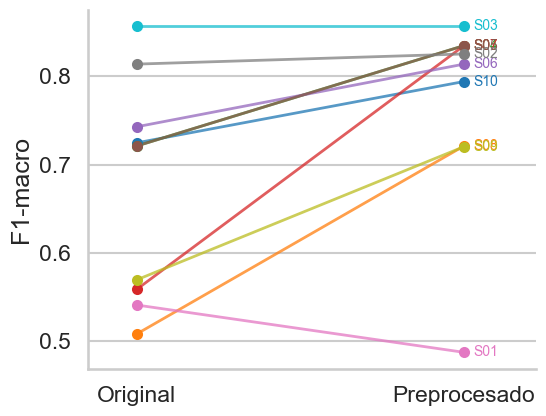

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

slope_df = (
    raw_folds_df[["fold", "test_users", "f1_macro"]]
    .rename(columns={"f1_macro": "raw_f1"})
    .merge(
        processed_folds_df[["fold", "test_users", "f1_macro"]].rename(columns={"f1_macro": "processed_f1"}),
        on=["fold", "test_users"],
        how="inner",
    )
    .sort_values("fold")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(5.8, 4.5))

x_positions = [0, 1]
palette = sns.color_palette("tab10", n_colors=len(slope_df))

for color, row in zip(palette, slope_df.itertuples(index=False)):
    ax.plot(
        x_positions,
        [row.raw_f1, row.processed_f1],
        color=color,
        linewidth=2,
        alpha=0.75,
        zorder=2,
    )
    ax.scatter(
        x_positions,
        [row.raw_f1, row.processed_f1],
        color=color,
        s=42,
        zorder=3,
    )
    ax.text(
        1.03,
        row.processed_f1,
        row.test_users,
        fontsize=10,
        va="center",
        color=color,
    )

ax.set_xlim(-0.15, 1.22)
ax.set_xticks(x_positions)
ax.set_xticklabels(["Original", "Preprocesado"])
ax.set_ylabel("F1-macro")
ax.grid(axis="x", visible=False)

plt.tight_layout()

fig.savefig(
    "f1_impact.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
